<center><h1><font color='darkblue'>Elektrotehnički fakultet Beograd,RMFP</font></h1></center>

# Modeli u medicini, 02. septembar, 2025. godine

> Add blockquote



Luka Puco 24/0091

<font color='red'>
Preimenovati svesku: File/Rename u [4] medicina_ime_prezime<br>
Redovno snimati aktuelnu verziju sveske: File/Save and Checkpoint <br>
Snimati fajl: Download as Notebook (.ipynb) </font>

#### __Zadatak 1__: SIR model
Deterministički SIR model epidemije je predstavljen sistemom diferencijalnih jednačina prvog reda koje opisuju odgovarajuće kompartmane:

\begin{align}
    \frac{dS}{dt} &= - \alpha SI\\
    \frac{dI}{dt} &= \alpha SI - \beta I\\
    \frac{dR}{dt} &= \beta I
\end{align}

gde je $S$ broj jedinki podložnih oboljevanju, $I$ broj zaraženih jedinki, $R$ broj uklonjenih jedinki, $\alpha$ konstanta brzine infekcije i $\beta$ konstanta brzine oporavka.

Na početku epidemije 100 jedinki zaraženih virusom SARS-CoV-2 ulazi u izolovanu podložnu populaciju od $10^6$ jedinki. Konstante brzine koje definišu širenje virusa su $\alpha = 2.25\times 10^{-6}$ i $\beta = 1$ i definišu se na nedeljnoj (sedmičnoj) bazi.

a) Forimirati Python definiciju (<font color='blue'>SIR</font>) koja opsiuje navedeni sistem diferencijalnih jednačina i zadati joj pozivne parametre $\alpha$ i $\beta$ kao argumente.

Rešiti sistem diferencijalnih jednačina na domenu od $0$ do $25$ nedelja (dovoljno je u $2000$ tačaka) sa početnim uslovima koji su naznačeni u opisu početka epidemije. Nacrtati zavisnosti $S(t)$ (plavom bojom), $I(t)$ (crvenom bojom) i $R(t)$ (zelenom bojom) na istom grafiku. Označiti ose grafika i identifikovati krive zavisnosti dodavanjem odgovarajuće legende. Koliko nedelja je potrebno da epidemija dostigne svoj maksimum? Koliko iznosi maksimalni broj zaraženih jedinki za date parametre? Koliko vremena mora proteći da bi samo $0.5\%$ populacije ostalo zaraženo? Za nalaženje maskimuma koristiti neku od ugrađenih Python funkcija.

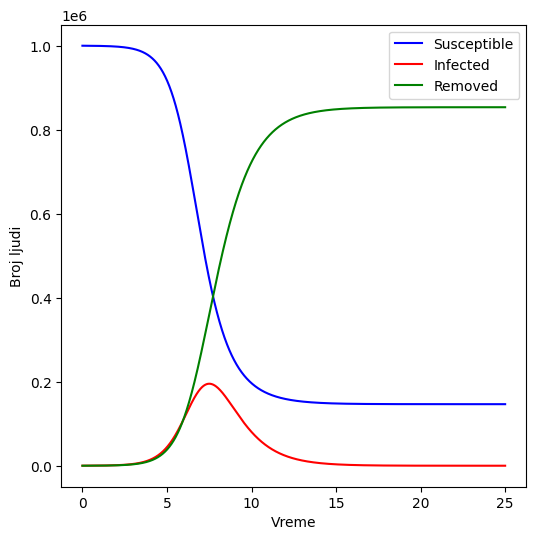

In [1]:
import numpy as np
import scipy.integrate
import matplotlib.pyplot as plt

def SIR(y, t, alfa, beta):
    S, I, R = y
    return [-alfa*S*I, alfa*S*I - beta*I, beta*I]

vreme = np.linspace(0, 25, 2000)
alfa = 2.25e-6
beta = 1

rez = scipy.integrate.odeint(SIR, [1e6, 100, 0], vreme, args=(alfa, beta))

plt.figure(figsize=(6,6))
plt.plot(vreme, rez[:,0], label="Susceptible",color='blue')
plt.plot(vreme, rez[:,1], label="Infected",color='red')
plt.plot(vreme, rez[:,2], label="Removed",color='green')
plt.legend()
plt.xlabel("Vreme")
plt.ylabel("Broj ljudi")
plt.show()


In [2]:
print(f"potrebno je {np.argmax(rez[:,1])} nedelja da se dostigne maksimum zaraze i tada je zaraženo {int(np.max(rez[:,1]))} ljudi")

potrebno je 600 nedelja da se dostigne maksimum zaraze i tada je zaraženo 195241 ljudi


In [3]:
lista=[]
for infected in zip(rez[:,1],vreme):
    if round(infected[0]/1e6,3) == 0.005:
        lista.append(infected)
print(f"potrebno je {int(lista[-1][1])} nedelja da ostane 0.5% populacije zarazeno")

potrebno je 14 nedelja da ostane 0.5% populacije zarazeno


Uneti komentar, odgovore na postavljena pitanja.

b) Ilustrovati i komentarisati evoluciju epidemije počevši od stanja potpune podložnosti populacije za tri različita slučaja koji oslikavaju karakteristične opsege osnovnog reprodukcionog broja ($R_{0} < 1, R_{0} = 1, R_{0} > 1$). Rešiti sistem diferencijalnih jednačina. Domen rešavanja prilagoditi dinamici evolucije epidemije. Nacrtati krive evolucije epidemije $S(t)$ (plavom bojom), $I(t)$ (crvenom bojom) i $R(t)$ (zelenom bojom) na istom grafiku za pojedinačne slučajeve. Označiti ose grafika i identifikovati krive zavisnosti dodavanjem odgovarajuće legende. Svakoj slici pridružiti odgovarajuću vrednost osnovnog reprodukcionog broja kao naslov grafika. Za koje vrednosti reprodukcionog broja možemo reći da dovode do epidemije? Da li u slučaju endemije postoji prenošenje bolesti ili uvek iste jedinke ostaju zaražene? Kako se to može proveriti na osnovu krive evolucije epidemije $R(t)$?

Hint: Videti slajd 20 za parametre koji definišu $R_{0}$. U skladu sa vrednostima $R_{0}$ menjati vrednost parametra $\alpha$ u programskom kodu.

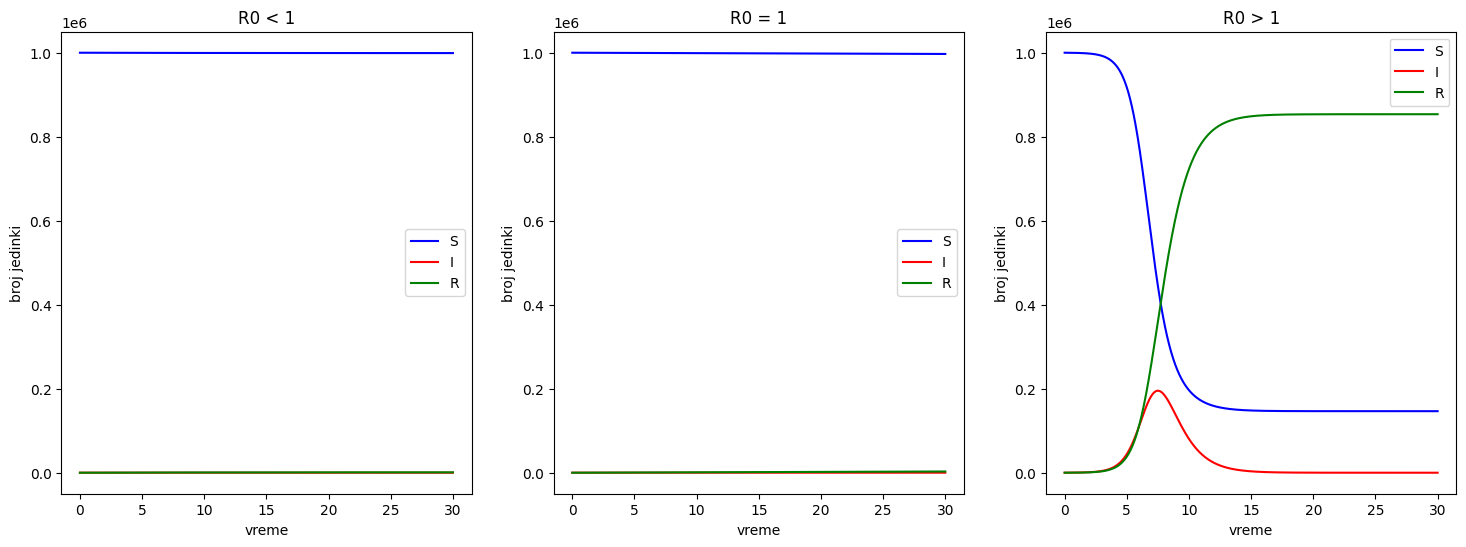

999147 je podlozno za R0<1


In [53]:

manje=0.9*1e-6
jednako=1e-6
vece=2.25*1e-6
rezmanje=scipy.integrate.odeint(SIR,[1e6,100,0],vreme,args=(manje,beta,))
rezjednako=scipy.integrate.odeint(SIR,[1e6,100,0],vreme,args=(jednako,beta,))
rezvece=scipy.integrate.odeint(SIR,[1e6,100,0],vreme,args=(vece,beta,))


plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.plot(vreme, rezmanje[:,0], 'blue', label="S")
plt.plot(vreme, rezmanje[:,1], 'red', label="I")
plt.plot(vreme, rezmanje[:,2], 'green', label="R")
plt.title("R0 < 1")
plt.xlabel("vreme")
plt.ylabel("broj jedinki")
plt.legend()

plt.subplot(1,3,2)
plt.plot(vreme, rezjednako[:,0], 'blue', label="S")
plt.plot(vreme, rezjednako[:,1], 'red', label="I")
plt.plot(vreme, rezjednako[:,2], 'green', label="R")
plt.title("R0 = 1")
plt.xlabel("vreme")
plt.ylabel("broj jedinki")
plt.legend()

plt.subplot(1,3,3)
plt.plot(vreme, rezvece[:,0], 'blue', label="S")
plt.plot(vreme, rezvece[:,1], 'red', label="I")
plt.plot(vreme, rezvece[:,2], 'green', label="R")
plt.title("R0 > 1")
plt.xlabel("vreme")
plt.ylabel("broj jedinki")
plt.legend()
plt.show()
print(f"{int(rezmanje[-1,0])} je podlozno za R0<1")

ako je R>1 onda dolazi do epidemije jer se broj zarazenih povecava. U slucaju endemije (R=1) svaka osoba tacno zarazi jednom drugu osobu. Lako se moze shvatiti da li je R0>0, jer je razlika izmedju grafika ocigledna.

Uneti komentar, odgovore na postavljena pitanja.

c) Naći maksimalan broj zaraženih tokom evolucije epidemije koja polazi iz stanja potpune podložnosti populacije (isti početni uslovi kao na početku zadatka), ukoliko je u pitanju širenje tri tipa virusa: influence (gripa) ($R_{0} = 3$), polia ($R_{0} = 6$) i rubeola ($R_{0} = 15$). Odgovarajuće sisteme jednačina rešavati na domenu od $0$ do $15$ nedelja. Priložiti dobijene vrednosti i nacrtati grafike vremenskih evolucija različitih kompartmana populacije $S(t)$ (plavom bojom), $I(t)$ (crvenom bojom) i $R(t)$ (zelenom bojom) na istom grafiku za pojedinačne slučajeve. Označiti ose grafika i identifikovati krive zavisnosti dodavanjem odgovarajuće legende. Svakoj slici pridružiti naziv virusa i odgovarajuću vrednost osnovnog reprodukcionog broja kao naslov grafika. Kako vrednost $R_{0}$ utiče na dinamiku epidemije?

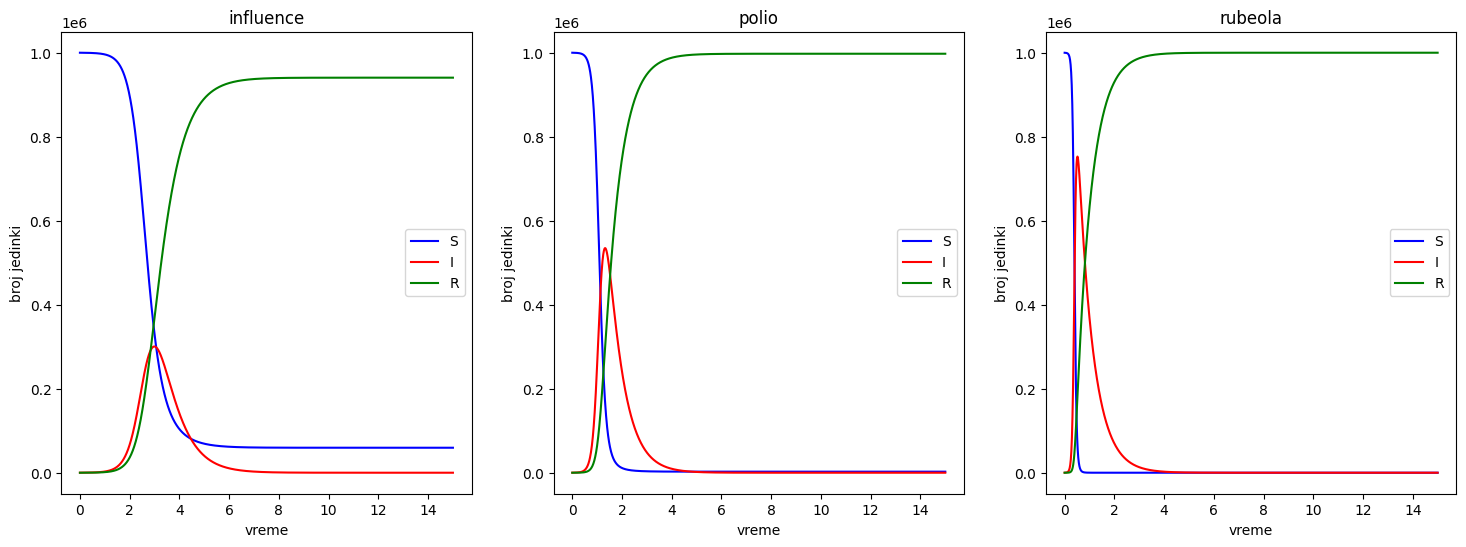

In [5]:
influence=3*1e-6
polio=6*1e-6
rubeola=15*1e-6
rezinfluence=scipy.integrate.odeint(SIR,[1e6,100,0],vreme,args=(influence,beta,))
rezpolio=scipy.integrate.odeint(SIR,[1e6,100,0],vreme,args=(polio,beta,))
rezrubeola=scipy.integrate.odeint(SIR,[1e6,100,0],vreme,args=(rubeola,beta,))
vreme = np.linspace(0, 15, 2000)
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.plot(vreme, rezinfluence[:,0], 'blue', label="S")
plt.plot(vreme, rezinfluence[:,1], 'red', label="I")
plt.plot(vreme, rezinfluence[:,2], 'green', label="R")
plt.title("influence")
plt.xlabel("vreme")
plt.ylabel("broj jedinki")
plt.legend()

plt.subplot(1,3,2)
plt.plot(vreme, rezpolio[:,0], 'blue', label="S")
plt.plot(vreme, rezpolio[:,1], 'red', label="I")
plt.plot(vreme, rezpolio[:,2], 'green', label="R")
plt.title("polio")
plt.xlabel("vreme")
plt.ylabel("broj jedinki")
plt.legend()

plt.subplot(1,3,3)
plt.plot(vreme, rezrubeola[:,0], 'blue', label="S")
plt.plot(vreme, rezrubeola[:,1], 'red', label="I")
plt.plot(vreme, rezrubeola[:,2], 'green', label="R")
plt.title("rubeola")
plt.xlabel("vreme")
plt.ylabel("broj jedinki")
plt.legend()


plt.show()


Sto je vece R to je epidemija jaca i brza, kao sto se vidi iz grafikona.

d) Koje procentualne udele populacije jedinki je neophodno imunizovati da bi se sprečilo širenje virusa iz prethodne tačke u navedenoj izolovanoj populaciji? Hint: Videti slajd 20. Iskoristiti relaciju sa slajda za izračunavanje udela populacije u $\%$. Navesti dobijene vrednosti za svaki od virusa.


In [6]:
print(f"za influence je potrebno {2/3}% populacije")
print(f"za polio je potrebno {5/6}% populacije")
print(f"za rubeolu je potrebno {14/15}% populacije")

za influence je potrebno 0.6666666666666666% populacije
za polio je potrebno 0.8333333333333334% populacije
za rubeolu je potrebno 0.9333333333333333% populacije


ako je R0 vece epidemija bukne brze i veci broj ljudi postane inficiran, ali ce epidemija krace da traje.

#### __Zadatak 2__: SIR model sa modelovanjem gubitka imuliteta - SIRS model

Modifikacijom SIR modela epidemije moguće je konstruisati SIRS model epidemije koji uključuje i mogućnost gubitka imuniteta jedinki, npr. usled mutacija virusa tokom epidemije. U tom slučaju, dodaje se još jedna konstanta brzine $\gamma$ koja opisuje gubitak imuniteta, i tada se sistem diferencijalnih jednačina prvog reda koji opisuje kompartmane izražava na sledeći način:

\begin{align}
    \frac{dS}{dt} &= - \alpha SI + \gamma R\\
    \frac{dI}{dt} &= \alpha SI - \beta I\\
    \frac{dR}{dr} &= \beta I - \gamma R
\end{align}

gde je $S$ broj jedinki podložnih obolevanju, $I$ broj zaraženih jedinki, $R$ broj uklonjenih jedinki, $\alpha$ konstanta brzine infekcije, $\beta$ konstanta brzine oporavka i $\gamma$ konstanta brzine gubitka imuniteta.


Na početku epidemije, $100$ jedinki zaraženih virusom SARS-CoV-2 ulazi u izolovanu podložnu populaciju od $10^6$ jedinki. Konstante brzine koje definišu širenje virusa su $\alpha = 2.65\times 10^{-6}$, $\beta = 1$ i $
\gamma= 0.35$ i definišu se na nedeljnoj (sedmičnoj) bazi.


a)	Formirati Python definiciju (<font color='blue'>SIRS</font>) koja opisuje navedeni sistem diferencijalnih jednačina i zadati joj odgovarajuće pozivne parametre $\alpha$, $\beta$ i $\gamma$ kao argumente.

Rešiti sistem diferencijalnih jednačina na domenu od $0$ do $30$ nedelja sa početnim uslovima koji su naznačeni u opisu početka epidemije. Nacrtati zavisnosti $S(t)$ (plavom bojom), $I(t)$ (crvenom bojom) i $R(t)$ (zelenom bojom) na istom grafiku. Označiti ose grafika i identifikovati krive zavisnosti dodavanjem odgovarajuće legende. Koliko nedelja je potrebno da epidemija dostigne stacionarno stanje? Koji broj jedinki će ostati zaražen tokom stacionarnog stanja?

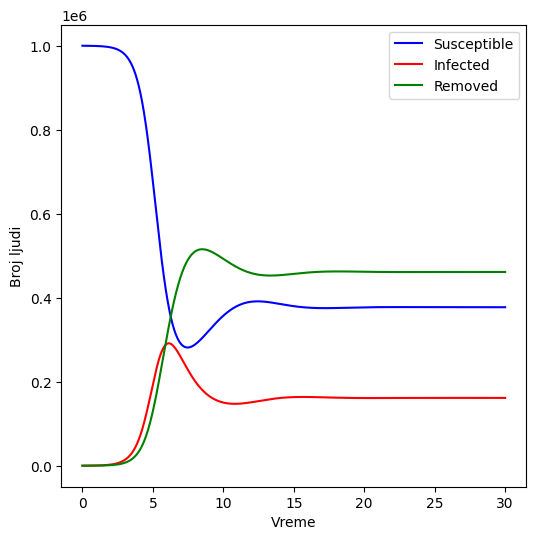

In [7]:
def SIRS(y,t, alfa, beta, gamma):
    S, I, R = y
    return [-alfa*S*I + gamma*R, alfa*S*I - beta*I, beta*I - gamma*R]
alfa=2.65*1e-6
beta=1
gamma=0.35
vreme = np.linspace(0, 30, 2000)
resenje = scipy.integrate.odeint(SIRS, [1e6, 100, 0], vreme, args=(alfa, beta, gamma,))
plt.figure(figsize=(6,6))
plt.plot(vreme, resenje[:,0], label="Susceptible",color='blue')
plt.plot(vreme, resenje[:,1], label="Infected",color='red')
plt.plot(vreme, resenje[:,2], label="Removed",color='green')
plt.legend()
plt.xlabel("Vreme")
plt.ylabel("Broj ljudi")
plt.show()

na 15 nedelji se dostize stacionarno stanje.

In [8]:
print(f"ostace zarazeno {int(resenje[-1][1])} ljudi u stacionarnom stanju")

ostace zarazeno 161443 ljudi u stacionarnom stanju


b)	Variranjem vrednosti parametra $\gamma$ uočiti njegov uticaj na stabilizaciju broja zaraženih tokom evolucije epidemije. Kom fizičkom parametru vezanom za proces oscilacija približno odgovara parametar $\gamma$? Ukoliko je potrebno, obrazloženje potkrepiti graficima (ubaciti nove ćelije u Jupyter fajl).

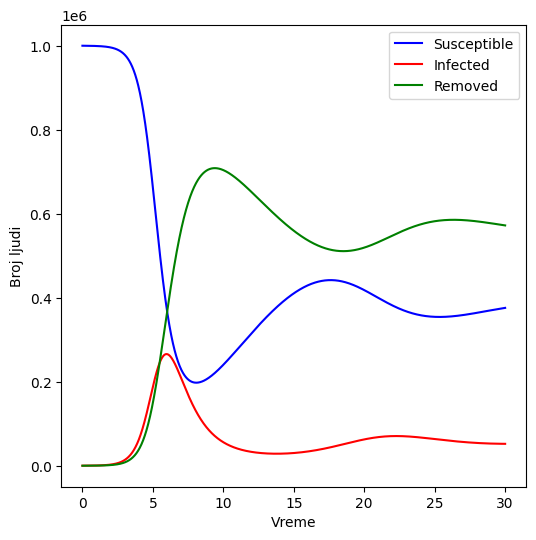

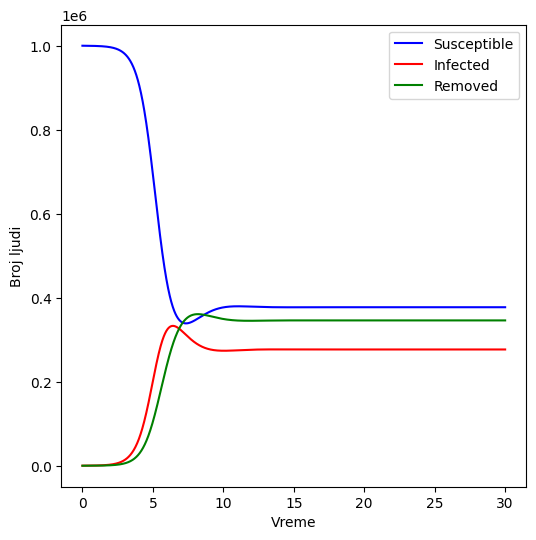

In [9]:
gamma=0.1
resenje = scipy.integrate.odeint(SIRS, [1e6, 100, 0], vreme, args=(alfa, beta, gamma,))
plt.figure(figsize=(6,6))
plt.plot(vreme, resenje[:,0], label="Susceptible",color='blue')
plt.plot(vreme, resenje[:,1], label="Infected",color='red')
plt.plot(vreme, resenje[:,2], label="Removed",color='green')
plt.legend()
plt.xlabel("Vreme")
plt.ylabel("Broj ljudi")
plt.show()

gamma=0.8
resenje = scipy.integrate.odeint(SIRS, [1e6, 100, 0], vreme, args=(alfa, beta, gamma,))
plt.figure(figsize=(6,6))
plt.plot(vreme, resenje[:,0], label="Susceptible",color='blue')
plt.plot(vreme, resenje[:,1], label="Infected",color='red')
plt.plot(vreme, resenje[:,2], label="Removed",color='green')
plt.legend()
plt.xlabel("Vreme")
plt.ylabel("Broj ljudi")
plt.show()


gamma ovde se moze poistovetiti sa prigusenjem, ako je vece onda ce brze da se smire trajektorije, a ako je sporije vise ce im trebati vremena.

#### __Zadatak 3__: SIR model sa modelovanjem kontinualnog sprovođenja mera karantina - SIRQ model

Modifikacijom SIR modela epidemije moguće je konstruisati i SIRQ model epidemije koji uključuje mogućnost kontinualnog sprovođenja mera karantina nad određenim brojem zaraženih jedinki na nedeljnoj bazi tokom epidemije. Tada se sistem diferencijalnih jednačina prvog reda koji opisuje kompartmane izražava na sledeći način:

\begin{align}
    \frac{dS}{dt} &= - \alpha SI\\
    \frac{dI}{dt} &= \alpha SI - (\beta + q)I\\
    \frac{dR}{dr} &= (\beta + q)I
\end{align}

gde je $S$ broj jedinki podložnih obolevanju, $I$ broj zaraženih jedinki, $R$ broj uklonjenih jedinki, $\alpha$ konstanta brzine infekcije, $\beta$ konstanta brzine oporavka i $q$ konstanta brzine uklanjanja zaraženih jedinki iz populacije putem preventivnih mera u vidu karantina.

Na početku epidemije, $100$ jedinki zaraženih virusom SARS-CoV-2 ulazi u izolovanu podložnu populaciju od $10^6$ jedinki. Konstante brzine koje definišu širenje virusa su $\alpha = 2.65\times 10^{-6}$, $\beta = 1$ i definišu se na nedeljnoj (sedmičnoj) bazi.

a)	Formirati Python definiciju (<font color='blue'>SIRQ</font>) koja opisuje navedeni sistem diferencijalnih jednačina i zadati joj odgovarajuće pozivne parametre $\alpha$, $\beta$ i $\gamma$ kao argumente.

rešiti sistem diferencijalnih jednačina na domenu od $0$ do $30$ nedelja sa početnim uslovima koji su naznačeni u opisu početka epidemije za tri vrednosti konstante $q$ ($q = 0.1$, $q = 0.5$ i $q = 1$). Nacrtati zavisnosti $S(t)$ (plavom bojom), $I(t)$ (crvenom bojom) i $R(t)$ (zelenom bojom) na istom grafiku. Označiti ose grafika i identifikovati krive zavisnosti dodavanjem odgovarajuće legende. Na osnovu analiza vremenskih evolucija epidemije, obrazložiti kako vrednost konstante brzine uklanjanja zaraženih jedinki iz populacije putem preventivnih mera u vidu karantina $q$ utiče na trajanje epidemije, maksimalan broj zaraženih jedinki tokom epidemije i vreme od početka epidemije kada broj zaraženih jedinki dostiže maksimum. Koji procenat jedinki u populaciji ostaje podložan tokom epidemija u analiziranim slučajevima?

Hint: Epidemija se može smatrati završenom u trenutku kada je $I < 0.5\%$ populacije (nakon dostizanja maksimuma).

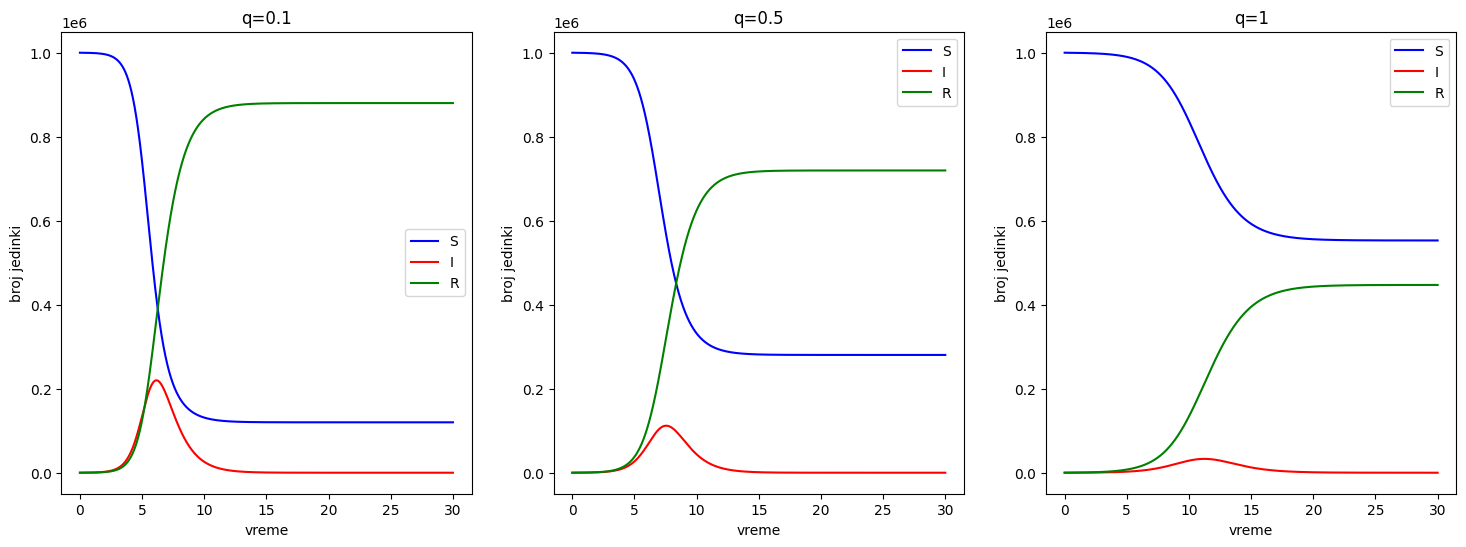

za q=0.1 je potrebno 9.25 nedelja da broj inficiranih padne ispod 5% populacije
za q=0.5 je potrebno 9.96 nedelja da broj inficiranih padne ispod 5% populacije
za q=1 je potrebno 11.23 nedelja da broj inficiranih padne ispod 5% populacije
maksimalan broj inficiranih za q=0.1 je 220034 i to se desava za 6 nedelja
maksimalan broj inficiranih za q=0.5 je 111932 i to se desava za 7 nedelja
maksimalan broj inficiranih za q=1 je 32996 i to se desava za 11 nedelja
za q=0.1 je podlozno 12.000382116296565% ljudi
za q=0.5 je podlozno 28.043787083586093% ljudi
za q=1 je podlozno 55.2992761733342% ljudi


In [51]:
def SIRQ(y,t, alfa, beta, gamma, q):
    S, I, R = y
    return [-alfa*S*I, alfa*S*I - (beta+q)*I , (q+beta)*I]
vreme=np.linspace(0,30,2000)
resenje1 = scipy.integrate.odeint(SIRQ, [1e6, 100, 0], vreme, args=(alfa, beta, gamma, 0.1,))
resenje2 = scipy.integrate.odeint(SIRQ, [1e6, 100, 0], vreme, args=(alfa, beta, gamma, 0.5,))
resenje3 = scipy.integrate.odeint(SIRQ, [1e6, 100, 0], vreme, args=(alfa, beta, gamma, 1,))
plt.figure(figsize=(18,6))
plt.subplot(1,3,1)
plt.plot(vreme, resenje1[:,0], 'blue', label="S")
plt.plot(vreme, resenje1[:,1], 'red', label="I")
plt.plot(vreme, resenje1[:,2], 'green', label="R")
plt.title("q=0.1")
plt.xlabel("vreme")
plt.ylabel("broj jedinki")
plt.legend()
plt.subplot(1,3,2)
plt.plot(vreme, resenje2[:,0], 'blue', label="S")
plt.plot(vreme, resenje2[:,1], 'red', label="I")
plt.plot(vreme, resenje2[:,2], 'green', label="R")
plt.title("q=0.5")
plt.xlabel("vreme")
plt.ylabel("broj jedinki")
plt.legend()
plt.subplot(1,3,3)
plt.plot(vreme, resenje3[:,0], 'blue', label="S")
plt.plot(vreme, resenje3[:,1], 'red', label="I")
plt.plot(vreme, resenje3[:,2], 'green', label="R")
plt.title("q=1")
plt.xlabel("vreme")
plt.ylabel("broj jedinki")
plt.legend()
plt.show()
m1=np.max(resenje1[:,1])
da=False
for i,x in enumerate(resenje1):
    if x[1]==m1:
        da=True
    if round((int(x[1])/1e6),2)<0.05 and da==True:
        time1=i*(30/2000)
        break
m1=np.max(resenje2[:,1])
da=False
for i,x in enumerate(resenje2):
    if x[1]==m1:
        da=True
    if round((int(x[1])/1e6),2)<0.05 and da==True:
        time2=i*(30/2000)
        break
m1=np.max(resenje3[:,1])
da=False
for i,x in enumerate(resenje3):
    if x[1]==m1:
        da=True
    if round((int(x[1])/1e6),2)<0.05 and da==True:
        time3=i*(30/2000)
        break

print(f"za q=0.1 je potrebno {round(time1,2)} nedelja da broj inficiranih padne ispod 5% populacije")
print(f"za q=0.5 je potrebno {round(time2,2)} nedelja da broj inficiranih padne ispod 5% populacije")
print(f"za q=1 je potrebno {round(time3,2)} nedelja da broj inficiranih padne ispod 5% populacije")

print(f"maksimalan broj inficiranih za q=0.1 je {int(np.max(resenje1[:,1]))} i to se desava za {int(vreme[np.argmax(resenje1[:,1])])} nedelja")
print(f"maksimalan broj inficiranih za q=0.5 je {int(np.max(resenje2[:,1]))} i to se desava za {int(vreme[np.argmax(resenje2[:,1])])} nedelja")
print(f"maksimalan broj inficiranih za q=1 je {int(np.max(resenje3[:,1]))} i to se desava za {int(vreme[np.argmax(resenje3[:,1])])} nedelja")
print(f"za q=0.1 je podlozno {(resenje1[-1,0]/1e6)*100}% ljudi")
print(f"za q=0.5 je podlozno {(resenje2[-1,0]/1e6)*100}% ljudi")
print(f"za q=1 je podlozno {(resenje3[-1,0]/1e6)*100}% ljudi")

ako je q veci:
maksimalni broj zarazenih opada;
ostaje vise ljudi nezarezeno;
manje ljudi prezivi bolest; 
sa porastom q kriva postaje spljosnatija, ali baza je sira, pa ce epidemija duze da traje, kao sto se moze videti.

***
<font color='red'>Snimiti aktuelnu verziju sveske: File/Save and Checkpoint <br>
Snimiti fajl: Download as Notebook (.ipynb) </font>
***

#### __Zadatak 4__: SIR model sa modelovanjem prenosa informacija o epidemiji  - ISIR model

Modifikacijom SIR modela epidemije moguće je konstruisati i unapređeni ISIR model epidemije koji uključuje mogućnost prenosa informacija o epidemiji i preduzimanja osnovnih preventivnih mera od strane određenog broja podložnih jedinki na nedeljnoj bazi tokom epidemije. U ISIR modelu se smatra da se sa povećanjem broja zaraženih jedinki ubrzava širenje informacija o epidemiji i time pojačavaju osnovne preventivne mere, što se opisuje sledećom funkcijom:

\begin{equation}
    \alpha(I) = \frac{\alpha_{0}}{1 + kI}
\end{equation}

gde je $\alpha_{0}$ početna konstanta brzine infekcije, $I$ broj zaraženih jedinki, $k$ konstanta koja opisuje uticaj prenosa informacija o epidemiji i $\alpha(I)$ konstanta brzine infekcije koja zavisi od trenutne vrednosti $I$.  
Tada se sistem diferencijalnih jednačina prvog reda koji opisuje kompartmane izražava na sledeći način:

\begin{align}
    \frac{dS}{dt} &= -\alpha(I) SI\\
    \frac{dI}{dt} &= \alpha(I) SI - \beta I\\
    \frac{dR}{dt} &= \beta I\\
\end{align}

gde je $S$ broj jedinki podložnih oboljevanju, $R$ broj uklonjenih jedinki i $\beta$ konstanta brzine oporavka.

Na početku epidemije, $100$ jedinki zaraženih virusom SARS-CoV-2 ulazi u izolovanu podložnu populaciju od $10^6$ jedinki. Od samog početka epidemije kreće se sa informisanjem populacije što se opisuje konstantom $k$ na nedeljnoj (sedmičnoj) bazi. Konstante brzine koje definišu širenje virusa bez preduzimanja preventivnih mera su $\alpha_{0} = 2.65\times 10^{-6}$ i $\beta = 1$ i takođe se definišu na nedeljnoj (sedmičnoj) bazi.

a)	Formirati Python definiciju (<font color='blue'>ISIR</font>) koja opisuje navedeni sistem diferencijalnih jednačina i zadati joj odgovarajuće pozivne parametre $\alpha$, $\beta$ i $k$ kao argumente.

Rešiti sistem diferencijalnih jednačina na domenu od $0$ do $20$ nedelja sa početnim uslovima koji su naznačeni u opisu početka epidemije. Nacrtati zavisnosti $S(t)$ (plavom bojom), $I(t)$ (crvenom bojom) i $R(t)$ (zelenom bojom) na istom grafiku. Označiti ose grafika i identifikovati krive zavisnosti dodavanjem odgovarajuće legende.

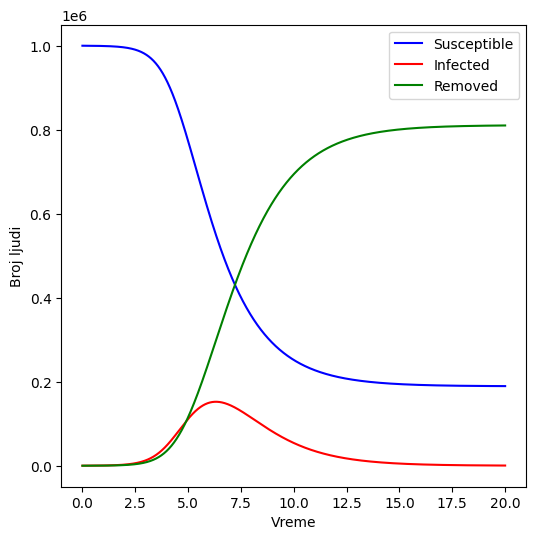

In [ ]:
def ISIR(y,t,alfa0, beta, k):
    S,I,R=y
    alfa=alfa0/(1+k*I)
    return [-alfa*S*I,alfa*S*I-beta*I,beta*I]
vreme = np.linspace(0, 20, 2000)
alfa0=2.65*1e-6
beta=1
resenje=scipy.integrate.odeint(ISIR,[1e6,100,0],vreme,args=(alfa0,beta,0.3*1e-5,))#nije dato koliko je k pa sam uzeo neku vrednost ja
plt.figure(figsize=(6,6))
plt.plot(vreme, resenje[:,0], label="Susceptible",color='blue')
plt.plot(vreme, resenje[:,1], label="Infected",color='red')
plt.plot(vreme, resenje[:,2], label="Removed",color='green')
plt.legend()
plt.xlabel("Vreme")
plt.ylabel("Broj ljudi")
plt.show()

b) Rešiti sistem diferencijalnih jednačina na domenu od $0$ do $30$ nedelja sa početnim uslovima koji su naznačeni u opisu početka epidemije za tri vrednosti konstante $k$ ($k = 0.3\times 10^{-5}$, $k = 0.8\times10^{-5}$ i $k = 1.7\times10^{-5}$). Nacrtati zavisnosti $S(t)$ (plavom bojom), $I(t)$ (crvenom bojom) i $R(t)$ (zelenom bojom) na istom grafiku. Označiti ose grafika i identifikovati krive zavisnosti dodavanjem odgovarajuće legende. Na osnovu analiza vremenskih evolucija epidemije, obrazložiti kako vrednost konstante širenja informacija k utiče na trajanje epidemije, maksimalan broj zaraženih jedinki tokom epidemije i vreme od početka epidemije kada broj zaraženih jedinki dostiže maksimum. Koji procenat jedinki u populaciji ostaje podložan tokom epidemija u analiziranim slučajevima?

Hint: Epidemija se može smatrati završenom u trenutku kada je $I < 0.5\%$ populacije (nakon dostizanja maksimuma).

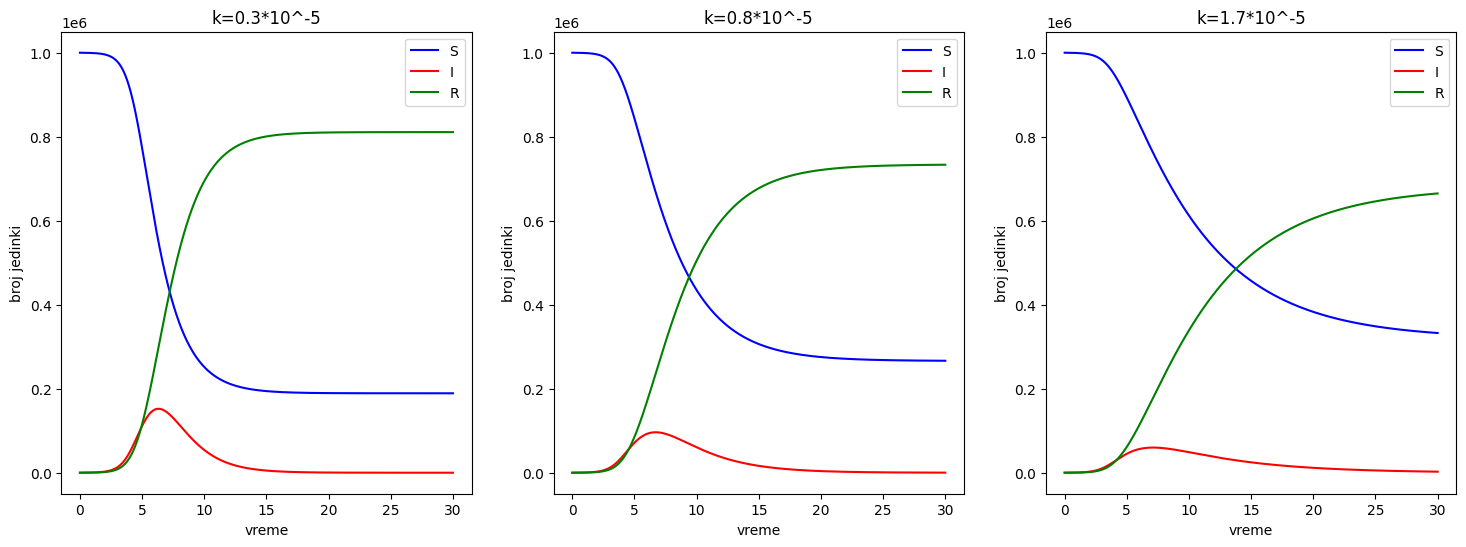

za k=0.3*10^-5 potrebno je 10 nedelja da broj inficiranih padne ispod 5%
za k=0.8*10^-5 potrebno je 11 nedelja da broj inficiranih padne ispod 5%
za k=1.7*10^-5 potrebno je 10 nedelja da broj inficiranih padne ispod 5%
za k=0.3*10^-5 maksimalan broj inficiranih je 152295 i to se desava za 6 nedelja
za k=0.8*10^-5 maksimalan broj inficiranih je 96358 i to se desava za 6 nedelja
za k=1.7*10^-5 maksimalan broj inficiranih je 59904 i to se desava za 7 nedelja
za k=0.3*10^-5 podlozno je 18.912471551285208% ljudi
za k=0.8*10^-5 podlozno je 26.65826254172201% ljudi
za k=1.7*10^-5 podlozno je 33.26453030483902% ljudi


In [49]:
vreme=np.linspace(0, 30, 2000)
resenje1=scipy.integrate.odeint(ISIR,[1e6,100,0],vreme,args=(alfa0,beta,0.3*1e-5,))
resenje2=scipy.integrate.odeint(ISIR,[1e6,100,0],vreme,args=(alfa0,beta,0.8*1e-5,))
resenje3=scipy.integrate.odeint(ISIR,[1e6,100,0],vreme,args=(alfa0,beta,1.7*1e-5,))
plt.figure(figsize=(18,6))
plt.subplot(1,3,1)
plt.plot(vreme, resenje1[:,0], 'blue', label="S")
plt.plot(vreme, resenje1[:,1], 'red', label="I")
plt.plot(vreme, resenje1[:,2], 'green', label="R")
plt.title("k=0.3*10^-5")
plt.xlabel("vreme")
plt.ylabel("broj jedinki")
plt.legend()
plt.subplot(1,3,2)
plt.plot(vreme, resenje2[:,0], 'blue', label="S")
plt.plot(vreme, resenje2[:,1], 'red', label="I")
plt.plot(vreme, resenje2[:,2], 'green', label="R")
plt.title("k=0.8*10^-5")
plt.xlabel("vreme")
plt.ylabel("broj jedinki")
plt.legend()
plt.subplot(1,3,3)
plt.plot(vreme, resenje3[:,0], 'blue', label="S")
plt.plot(vreme, resenje3[:,1], 'red', label="I")
plt.plot(vreme, resenje3[:,2], 'green', label="R")
plt.title("k=1.7*10^-5")
plt.xlabel("vreme")
plt.ylabel("broj jedinki")
plt.legend()
plt.show()
m1=np.max(resenje1[:,1])
da=False
for i,x in enumerate(resenje1):
    if x[1]==m1:
        da=True
    if round((int(x[1])/1e6),2)<0.05 and da==True:
        time1=i*(30/2000)
        break
m1=np.max(resenje2[:,1])
da=False
for i,x in enumerate(resenje2):
    if x[1]==m1:
        da=True
    if round((int(x[1])/1e6),2)<0.05 and da==True:
        time2=i*(30/2000)
        break
m1=np.max(resenje3[:,1])
da=False
for i,x in enumerate(resenje3):
    if x[1]==m1:
        da=True
    if round((int(x[1])/1e6),2)<0.05 and da==True:
        time3=i*(30/2000)
        break
print(f"za k=0.3*10^-5 potrebno je {int(time1)} nedelja da broj inficiranih padne ispod 5%")
print(f"za k=0.8*10^-5 potrebno je {int(time2)} nedelja da broj inficiranih padne ispod 5%")
print(f"za k=1.7*10^-5 potrebno je {int(time3)} nedelja da broj inficiranih padne ispod 5%")

maxbroj1=int(np.max(resenje1[:,1]))
maxbroj2=int(np.max(resenje2[:,1]))
maxbroj3=int(np.max(resenje3[:,1]))
kadamaxbroj1=int(np.argmax(resenje1[:,1]))
kadamaxbroj2=int(np.argmax(resenje2[:,1]))
kadamaxbroj3=int(np.argmax(resenje3[:,1]))
print(f"za k=0.3*10^-5 maksimalan broj inficiranih je {maxbroj1} i to se desava za {int(kadamaxbroj1*(30/2000))} nedelja")
print(f"za k=0.8*10^-5 maksimalan broj inficiranih je {maxbroj2} i to se desava za {int(kadamaxbroj2*(30/2000))} nedelja")
print(f"za k=1.7*10^-5 maksimalan broj inficiranih je {maxbroj3} i to se desava za {int(kadamaxbroj3*(30/2000))} nedelja")
print(f"za k=0.3*10^-5 podlozno je {(resenje1[-1,0]/1e6)*100}% ljudi")
print(f"za k=0.8*10^-5 podlozno je {(resenje2[-1,0]/1e6)*100}% ljudi")
print(f"za k=1.7*10^-5 podlozno je {(resenje3[-1,0]/1e6)*100}% ljudi")

ako k tezi 0 onda model pocinje da lici na SIR. ako k tezi vecem broju onda ce sa porastom I da se gusi epidemija. ako je k vece vise ljudi ce da zna za epidemiju i cuvace se bolesti, pa ce se epidemija ranije zavrsiti.

#### __Zadatak 5__: SIR model sa modelovanjem efekta perioda inkubacije na širenje bolesti - SEIR model

Modifikacijom SIR modela epidemije moguće je konstruisati i kompleksniji SEIR model epidemije koji uračunava efekat perioda inkubacije na širenje bolesti. U tom slučaju se mora uvesti dodatni kompartman za izložene jedinke koje još uvek nisu postale infektivne i konstanta brzine prelaska jedinki iz izložene u zaraženu (infektivnu) populaciju. Tada se sistem diferencijalnih jednačina prvog reda koji opisuje kompartmane proširuje i izražava na sledeći način:

\begin{align}
    \frac{dS}{dt} &= - \alpha SI\\
    \frac{dE}{dt} &= \alpha SI - \delta E\\
    \frac{dI}{dt} &= \delta E - \beta I\\
    \frac{dR}{dr} &= \beta I
\end{align}

gde je $S$ broj jedinki podložnih obolevanju, $E$ broj izloženih jedinki koje nisu infektivne, $I$ broj zaraženih jedinki koje su postale infektivne, $R$ broj uklonjenih jedinki, $\alpha$ konstanta brzine infekcije,$\beta$ konstanta brzine oporavka i $\delta$ konstanta brzine prelaska jedinki iz izložene u zaraženu (infektivnu) populaciju.

Na početku epidemije, $100$ jedinki zaraženih virusom SARS-CoV-2 ulazi u izolovanu podložnu populaciju od $10^6$ jedinki. Konstante brzine koje definišu širenje virusa su $\alpha = 2.65\times 10^{-6}$, $\beta = 1$ i definišu se na nedeljnoj (sedmičnoj) bazi.

a)	Formirati Python definiciju (<font color='blue'>SEIR</font>) koja opisuje navedeni sistem diferencijalnih jednačina i zadati joj odgovarajuće pozivne parametre $\alpha$, $\beta$ i $\delta$ kao argumente.

rešiti sistem diferencijalnih jednačina na domenu od $0$ do $52$ nedelje sa početnim uslovima koji su naznačeni u opisu početka epidemije za tri vrednosti konstante $\delta$ ($\delta = 0.3$, $\delta = 0.5$ i $\delta = 1$). Nacrtati zavisnosti $S(t)$ (plavom bojom), $E(t)$ (žutom bojom), $I(t)$ (crvenom bojom) i $R(t)$ (zelenom bojom) na istom grafiku. Označiti ose grafika i identifikovati krive zavisnosti dodavanjem odgovarajuće legende. Na osnovu analiza vremenskih evolucija epidemije, obrazložiti kako vrednost konstante brzine prelaska jedinki iz izložene u zaraženu (infektivnu) populaciju $\delta$ utiče na trajanje epidemije, maksimalan broj obolelih jedinki tokom epidemije (infektivnih i neinfektivnih) i vreme od početka epidemije kada broj obolelih jedinki dostiže maksimum u izloženoj i zaraženoj populaciji. Koji procenat jedinki u populaciji ostaje podložan tokom epidemija u analiziranim slučajevima? Uporediti karakteristike maksimuma krivih $E(t)$ i $I(t)$ i objasniti njihovu međusobnu vezu.

Hint: Epidemija se može smatrati završenom u trenutku kada je $I < 0.5\%$ populacije (nakon dostizanja maksimuma).

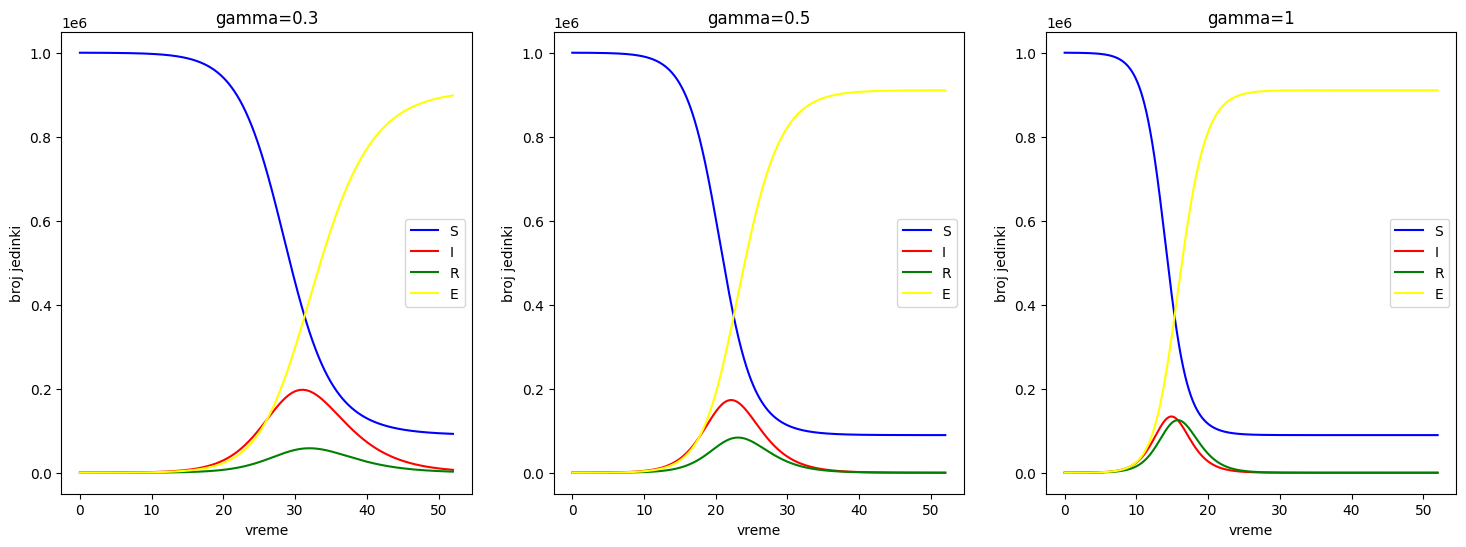

za gamma=0.3 potrebno je 42.61 nedelja da broj inficiranih padne ispod 5% populacije
za gamma=0.5 potrebno je 29.43 nedelja da broj inficiranih padne ispod 5% populacije
za gamma=1.0 potrebno je 18.9 nedelja da broj inficiranih padne ispod 5% populacije
gamma=0.3: max(E+I) = 254983 na t = 31 nedelja
gamma=0.5: max(E+I) = 254983 na t = 22 nedelja
gamma=1.0: max(E+I) = 254982 na t = 15 nedelja
89.82% populacije ostaje podlozno zarazi za gamma=0.3
91.05% populacije ostaje podlozno zarazi za gamma=0.5
91.05% populacije ostaje podlozno zarazi za gamma=1.0
broj u inkubatoru: 197481,broj inficiranih: 58255 za gamma=0.3
broj u inkubatoru: 173051,broj inficiranih: 83728 za gamma=0.5
broj u inkubatoru: 133902,broj inficiranih: 125165 za gamma=1.0


In [41]:
def SEIR(y, t, alfa, beta, gamma):
    S, E, I, R = y
    dS = -alfa * S * I
    dE =  alfa * S * I - gamma * E
    dI =  gamma * E - beta * I
    dR =  beta * I
    return [dS, dE, dI, dR]
vreme=np.linspace(0,52,4000)
resenje1=scipy.integrate.odeint(SEIR,[1e6,100,0,0],vreme,args=(alfa,beta,0.3,))
resenje2=scipy.integrate.odeint(SEIR,[1e6,100,0,0],vreme,args=(alfa,beta,0.5,))
resenje3=scipy.integrate.odeint(SEIR,[1e6,100,0,0],vreme,args=(alfa,beta,1,))
plt.figure(figsize=(18,6))
plt.subplot(1,3,1)
plt.plot(vreme, resenje1[:,0], 'blue', label="S")
plt.plot(vreme, resenje1[:,1], 'red', label="I")
plt.plot(vreme, resenje1[:,2], 'green', label="R")
plt.plot(vreme, resenje1[:,3], 'yellow', label="E")
plt.title("gamma=0.3")
plt.xlabel("vreme")
plt.ylabel("broj jedinki")
plt.legend()
plt.subplot(1,3,2)
plt.plot(vreme, resenje2[:,0], 'blue', label="S")
plt.plot(vreme, resenje2[:,1], 'red', label="I")
plt.plot(vreme, resenje2[:,2], 'green', label="R")
plt.plot(vreme, resenje2[:,3], 'yellow', label="E")
plt.title("gamma=0.5")
plt.xlabel("vreme")
plt.ylabel("broj jedinki")
plt.legend()
plt.subplot(1,3,3)
plt.plot(vreme, resenje3[:,0], 'blue', label="S")
plt.plot(vreme, resenje3[:,1], 'red', label="I")
plt.plot(vreme, resenje3[:,2], 'green', label="R")
plt.plot(vreme, resenje3[:,3], 'yellow', label="E")
plt.title("gamma=1")
plt.xlabel("vreme")
plt.ylabel("broj jedinki")
plt.legend()
plt.show()
m1=np.max(resenje1[:,1])
da=False
for i,x in enumerate(resenje1):
    if x[1]==m1:
        da=True
    if round((int(x[1])/1e6),2)<0.05 and da==True:
        time1=i*(52/4000)
        break
m1=np.max(resenje2[:,1])
da=False
for i,x in enumerate(resenje2):
    if x[1]==m1:
        da=True
    if round((int(x[1])/1e6),2)<0.05 and da==True:
        time2=i*(52/4000)
        break
m1=np.max(resenje3[:,1])
da=False
for i,x in enumerate(resenje3):
    if x[1]==m1:
        da=True
    if round((int(x[1])/1e6),2)<0.05 and da==True:
        time3=i*(52/4000)
        break
print(f"za gamma=0.3 potrebno je {round(time1,2)} nedelja da broj inficiranih padne ispod 5% populacije")
print(f"za gamma=0.5 potrebno je {round(time2,2)} nedelja da broj inficiranih padne ispod 5% populacije")
print(f"za gamma=1.0 potrebno je {round(time3,2)} nedelja da broj inficiranih padne ispod 5% populacije")

def max_ei(res):
    EI = res[:,1] + res[:,2]
    idx = np.argmax(EI)
    return EI[idx], vreme[idx]
m1, t1 = max_ei(resenje1)
m2, t2 = max_ei(resenje2)
m3, t3 = max_ei(resenje3)
print(f"gamma=0.3: max(E+I) = {int(m1)} na t = {int(t1)} nedelja")
print(f"gamma=0.5: max(E+I) = {int(m2)} na t = {int(t2)} nedelja")
print(f"gamma=1.0: max(E+I) = {int(m3)} na t = {int(t3)} nedelja")
print(f"{resenje1[-1][-1]/1e6*100:.2f}% populacije ostaje podlozno zarazi za gamma=0.3")
print(f"{resenje2[-1][-1]/1e6*100:.2f}% populacije ostaje podlozno zarazi za gamma=0.5")
print(f"{resenje3[-1][-1]/1e6*100:.2f}% populacije ostaje podlozno zarazi za gamma=1.0")
print(f"broj u inkubatoru: {int(np.max(resenje1[:,1]))},broj inficiranih: {int(np.max(resenje1[:,2]))} za gamma=0.3")
print(f"broj u inkubatoru: {int(np.max(resenje2[:,1]))},broj inficiranih: {int(np.max(resenje2[:,2]))} za gamma=0.5")
print(f"broj u inkubatoru: {int(np.max(resenje3[:,1]))},broj inficiranih: {int(np.max(resenje3[:,2]))} za gamma=1.0")

E uvek predvodi I, maksimum za E je veci i siri, povecanjem gamma razlika izmedju E i I se smanjuje. Ako je gamma vece brze ce da se zavrsi epidemija, sto je i ocekivano.

***
<font color='red'>Snimiti aktuelnu verziju sveske: File/Save and Checkpoint <br>
Snimiti fajl: Download as Notebook (.ipynb) </font>
***